# HC3-Trained SVM Cross-Dataset Evaluation

This experiment investigates whether AI-text detection performance depends strongly on the training dataset.

A TF-IDF + SVM classifier is trained only on the HC3 Human-vs-ChatGPT dataset.

The trained model is then evaluated on:

1. A held-out HC3 test set
2. The original Kaggle AI-vs-Human test set

No retraining is performed before evaluation on the Kaggle dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
import time

In [2]:
DATA_DIR = Path("../data/splits")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_TEST_FILE = DATA_DIR / "test.parquet"

print("Kaggle test exists:", KAGGLE_TEST_FILE.exists())

Kaggle test exists: True


In [3]:
hc3 = load_dataset(
    "json",
    data_files="hf://datasets/Hello-SimpleAI/HC3/all.jsonl"
)

hc3

DatasetDict({
    train: Dataset({
        features: ['question', 'human_answers', 'chatgpt_answers', 'index', 'source'],
        num_rows: 24322
    })
})

In [4]:
rows = []

for item in hc3["train"]:

    # Human = 0
    for answer in item["human_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "generated": 0
            })

    # ChatGPT = 1
    for answer in item["chatgpt_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "generated": 1
            })

hc3_df = pd.DataFrame(rows)

print("Initial HC3 shape:", hc3_df.shape)

hc3_df.head()

Initial HC3 shape: (85431, 2)


,text,generated
0,"Basically there are many categories of "" Best ...",0
1,"If you 're hearing about it , it 's because it...",0
2,"One reason is lots of catagories . However , h...",0
3,There are many different best seller lists tha...,1
4,salt is good for not dying in car crashes and ...,0


In [5]:
print(
    "Duplicates before removal:",
    hc3_df["text"].duplicated().sum()
)

hc3_df = hc3_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

print("Final HC3 shape:", hc3_df.shape)

Duplicates before removal: 6100
Final HC3 shape: (79331, 2)


In [6]:
print("Class counts:")
print(hc3_df["generated"].value_counts())

print("\nClass percentages:")
print(
    hc3_df["generated"].value_counts(
        normalize=True
    ) * 100
)

Class counts:
generated
0    53086
1    26245
Name: count, dtype: int64

Class percentages:
generated
0    66.917094
1    33.082906
Name: proportion, dtype: float64


In [7]:
hc3_train_df, hc3_temp_df = train_test_split(
    hc3_df,
    test_size=0.30,
    stratify=hc3_df["generated"],
    random_state=42
)

print("Train:", hc3_train_df.shape)
print("Temporary:", hc3_temp_df.shape)

Train: (55531, 2)
Temporary: (23800, 2)


In [8]:
hc3_train_df, hc3_temp_df = train_test_split(
    hc3_df,
    test_size=0.30,
    stratify=hc3_df["generated"],
    random_state=42
)

print("Train:", hc3_train_df.shape)
print("Temporary:", hc3_temp_df.shape)

Train: (55531, 2)
Temporary: (23800, 2)


In [10]:
hc3_val_df, hc3_test_df = train_test_split(
    hc3_temp_df,
    test_size=0.50,
    stratify=hc3_temp_df["generated"],
    random_state=42
)

print("Train:", hc3_train_df.shape)
print("Validation:", hc3_val_df.shape)
print("Test:", hc3_test_df.shape)

Train: (55531, 2)
Validation: (11900, 2)
Test: (11900, 2)


In [11]:
for name, df in [
    ("Train", hc3_train_df),
    ("Validation", hc3_val_df),
    ("Test", hc3_test_df)
]:
    print(f"\n{name}")
    print(
        df["generated"].value_counts(
            normalize=True
        )
    )


Train
generated
0    0.669176
1    0.330824
Name: proportion, dtype: float64

Validation
generated
0    0.66916
1    0.33084
Name: proportion, dtype: float64

Test
generated
0    0.66916
1    0.33084
Name: proportion, dtype: float64


In [12]:
X_train = hc3_train_df["text"]
y_train = hc3_train_df["generated"]

X_val = hc3_val_df["text"]
y_val = hc3_val_df["generated"]

X_test = hc3_test_df["text"]
y_test = hc3_test_df["generated"]

In [13]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    max_df=0.90
)

In [14]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_val_tfidf = tfidf.transform(
    X_val
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    "Train TF-IDF shape:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF shape:",
    X_val_tfidf.shape
)

print(
    "Test TF-IDF shape:",
    X_test_tfidf.shape
)

Train TF-IDF shape: (55531, 50000)
Validation TF-IDF shape: (11900, 50000)
Test TF-IDF shape: (11900, 50000)


In [15]:
hc3_svm = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

hc3_svm

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [16]:
start_time = time.perf_counter()

hc3_svm.fit(
    X_train_tfidf,
    y_train
)

training_time = (
    time.perf_counter()
    - start_time
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

Training time: 1.20 seconds


In [17]:
val_preds = hc3_svm.predict(
    X_val_tfidf
)

val_scores = hc3_svm.decision_function(
    X_val_tfidf
)

In [18]:
hc3_val_results = {
    "accuracy": accuracy_score(
        y_val,
        val_preds
    ),
    "precision": precision_score(
        y_val,
        val_preds,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        val_preds,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        val_preds,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val,
        val_scores
    )
}

hc3_val_results

{'accuracy': 0.9551260504201681,
 'precision': 0.922313229089104,
 'recall': 0.9438658877317755,
 'f1': 0.9329651016821491,
 'roc_auc': 0.9910747034855867}

In [19]:
hc3_test_preds = hc3_svm.predict(
    X_test_tfidf
)

hc3_test_scores = hc3_svm.decision_function(
    X_test_tfidf
)

In [20]:
hc3_test_results = {
    "accuracy": accuracy_score(
        y_test,
        hc3_test_preds
    ),
    "precision": precision_score(
        y_test,
        hc3_test_preds,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        hc3_test_preds,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        hc3_test_preds,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        hc3_test_scores
    )
}

hc3_test_results

{'accuracy': 0.9561344537815126,
 'precision': 0.9248569295844737,
 'recall': 0.9441198882397764,
 'f1': 0.9343891402714932,
 'roc_auc': 0.9909170655965324}

In [21]:
print(
    classification_report(
        y_test,
        hc3_test_preds,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

              precision    recall  f1-score   support

       Human       0.97      0.96      0.97      7963
          AI       0.92      0.94      0.93      3937

    accuracy                           0.96     11900
   macro avg       0.95      0.95      0.95     11900
weighted avg       0.96      0.96      0.96     11900



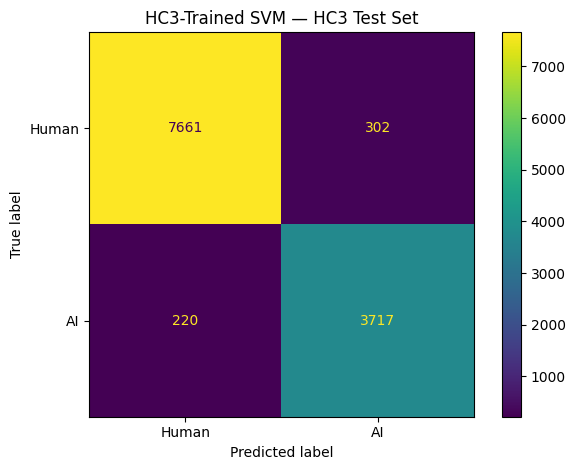

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    hc3_test_preds,
    display_labels=[
        "Human",
        "AI"
    ]
)

plt.title(
    "HC3-Trained SVM — HC3 Test Set"
)

plt.tight_layout()
plt.show()

In [23]:
kaggle_test_df = pd.read_parquet(
    KAGGLE_TEST_FILE
)

print(
    "Kaggle test shape:",
    kaggle_test_df.shape
)

kaggle_test_df.head()

Kaggle test shape: (73083, 3)


,text,generated,text_length
0,"Dear principal TEACHER_NAME,\n\nI have heard t...",0,1582
1,This is not valuable to have in a classroom wi...,0,1235
2,"In my personal opinion, I think that it would ...",0,990
3,Facial Action Coding System (FACS) is a unique...,1,2904
4,Have even seen the cowboys on TV and wanted to...,0,1576


In [24]:
print(
    kaggle_test_df.columns
)

print(
    kaggle_test_df[
        "generated"
    ].value_counts()
)

Index(['text', 'generated', 'text_length'], dtype='object')
generated
0    45870
1    27213
Name: count, dtype: int64


In [26]:
X_kaggle_external = tfidf.transform(
    kaggle_test_df["text"]
)

y_kaggle_external = kaggle_test_df["generated"]

print(
    "External Kaggle shape:",
    X_kaggle_external.shape
)

External Kaggle shape: (73083, 50000)


In [27]:
kaggle_external_preds = hc3_svm.predict(
    X_kaggle_external
)

kaggle_external_scores = hc3_svm.decision_function(
    X_kaggle_external
)

In [28]:
kaggle_external_results = {
    "accuracy": accuracy_score(
        y_kaggle_external,
        kaggle_external_preds
    ),
    "precision": precision_score(
        y_kaggle_external,
        kaggle_external_preds,
        zero_division=0
    ),
    "recall": recall_score(
        y_kaggle_external,
        kaggle_external_preds,
        zero_division=0
    ),
    "f1": f1_score(
        y_kaggle_external,
        kaggle_external_preds,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_kaggle_external,
        kaggle_external_scores
    )
}

kaggle_external_results

{'accuracy': 0.7511459573361794,
 'precision': 0.6486201672923665,
 'recall': 0.7237717267482453,
 'f1': 0.6841383143159833,
 'roc_auc': 0.8065584713656402}

In [29]:
cross_direction_df = pd.DataFrame([
    {
        "Training Dataset": "Kaggle",
        "Evaluation Dataset": "Kaggle",
        "F1": 0.999155
    },

    {
        "Training Dataset": "Kaggle",
        "Evaluation Dataset": "HC3",
        "F1": 0.570157
    },

    {
        "Training Dataset": "HC3",
        "Evaluation Dataset": "HC3",
        "F1": hc3_test_results["f1"]
    },

    {
        "Training Dataset": "HC3",
        "Evaluation Dataset": "Kaggle",
        "F1": kaggle_external_results["f1"]
    }
])

cross_direction_df

,Training Dataset,Evaluation Dataset,F1
0,Kaggle,Kaggle,0.999155
1,Kaggle,HC3,0.570157
2,HC3,HC3,0.934389
3,HC3,Kaggle,0.684138


In [30]:
cross_matrix = cross_direction_df.pivot(
    index="Training Dataset",
    columns="Evaluation Dataset",
    values="F1"
)

cross_matrix

Evaluation Dataset,HC3,Kaggle
Training Dataset,,
HC3,0.934389,0.684138
Kaggle,0.570157,0.999155


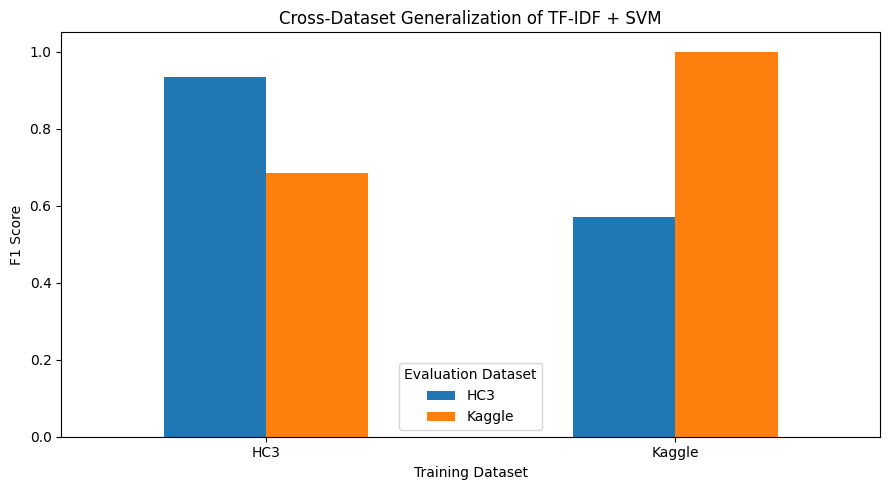

In [31]:
cross_matrix.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Cross-Dataset Generalization of TF-IDF + SVM"
)

plt.ylabel("F1 Score")
plt.xlabel("Training Dataset")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [32]:
HC3_MODEL_PATH = (
    MODEL_DIR
    / "hc3_tfidf_svm_model.joblib"
)

HC3_VECTORIZER_PATH = (
    MODEL_DIR
    / "hc3_tfidf_vectorizer.joblib"
)

joblib.dump(
    hc3_svm,
    HC3_MODEL_PATH
)

joblib.dump(
    tfidf,
    HC3_VECTORIZER_PATH
)

print("HC3 SVM saved.")

HC3 SVM saved.


In [33]:
final_results = pd.DataFrame([
    {
        "model": "HC3-trained TF-IDF + SVM",
        "evaluation_dataset": "HC3",
        **hc3_test_results
    },

    {
        "model": "HC3-trained TF-IDF + SVM",
        "evaluation_dataset": "Kaggle",
        **kaggle_external_results
    }
])

results_path = (
    OUTPUT_DIR
    / "hc3_trained_svm_cross_evaluation.csv"
)

final_results.to_csv(
    results_path,
    index=False
)

final_results

,model,evaluation_dataset,accuracy,precision,recall,f1,roc_auc
0,HC3-trained TF-IDF + SVM,HC3,0.956134,0.924857,0.944120,0.934389,0.990917
1,HC3-trained TF-IDF + SVM,Kaggle,0.751146,0.648620,0.723772,0.684138,0.806558
